# Exploratory Data Analysis

## Load data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import unicodedata, re
import matplotlib.ticker as mticker

plt.style.use('ggplot')
sns.set_theme(style="whitegrid")
sns.set_context("notebook")

df = pd.read_csv('D:/dataFest 2026/DataFest-2026-ENERGICAL-DS/LIVRABLE_DataFest2026_ENERGICAL/energical_transactions_anonymized.csv', index_col='id_transaction')
df.head()

,id_commande_anon,id_client,type_client,nouveau_ou_fidele,date_commande,wilaya,categorie_produit,produit,quantite,montant_da,moyen_paiement,statut_commande
id_transaction,,,,,,,,,,,,
1,10872,CLT_02355,B2C,Returning,2022-01-03,Laghouat,Électricité,Electrode détecteur,3.0,826.05,Paiement à la livraison,Terminée
2,12712,CLT_00422,B2C,New,2022-12-08,Adrar,Électricité,Interrupteur Simple Allumage DIAA Métal,4.0,2024.10,Paiement à la livraison,Terminée
3,17642,CLT_03812,B2C,Returning,2024-06-10,Mila,Sanitaire,Capteur de débit pour chauffe-eau à T° const,3.0,1271.90,Paiement à la livraison,En livraison par NOEST
4,16497,CLT_02886,B2C,Returning,2024-01-31,Boumerdès,Électricité,Prise simple DIAA Acrylique - Bois,2.0,702.05,Paiement à la livraison,Terminée
5,17671,CLT_00452,B2C,New,2024-06-13,Alger,Sanitaire,Chauffe-eau à température constante XCT-12L (G...,1.0,27352.74,Paiement à la livraison,Terminée


In [9]:
df['statut_commande'].unique()

array(['Terminée', 'En livraison par NOEST', 'Retour NOEST',
       'Partiellement remboursée', 'Remboursée', 'Attente paiement',
       'Partiellement payé', 'En attente'], dtype=object)

In [2]:
catalog = pd.read_csv('D:/dataFest 2026/DataFest-2026-ENERGICAL-DATA-INTELLIGENCE/energical_catalogue_produits.csv')
catalog.head()

,id_produit,nom_produit,categorie,sous_categorie,prix_da,description_courte,statut_stock,produit_alternatif_id,marge_estimee_pct,delai_reappro_jours
0,BS10 110110SC,Baignoire BS10,Sanitaire,Baignoires,12250.0,NaN,Disponible,NaN,33,29
1,WMA1C00C00,Mitigeur Amen Lavabo,Sanitaire,Robinetterie sanitaire > Amen,4190.0,NaN,Disponible,NaN,30,32
2,WMA7C00C00,Mitigeur Amen Bidet,Sanitaire,Robinetterie sanitaire > Amen,4190.0,NaN,Disponible,NaN,35,31
3,WMA2C00C00,Mitigeur Amen Cuisine,Sanitaire,Robinetterie sanitaire > Amen,5620.0,NaN,Disponible,NaN,32,31
4,WMA6C00C00,Mitigeur Amen Cuisine murale,Sanitaire,Robinetterie sanitaire > Amen,5620.0,NaN,Disponible,NaN,32,29


In [3]:
pd.set_option('display.max_rows', 300)

## Data Understanding

In [4]:
df.columns

Index(['id_commande_anon', 'id_client', 'type_client', 'nouveau_ou_fidele',
       'date_commande', 'wilaya', 'categorie_produit', 'produit', 'quantite',
       'montant_da', 'moyen_paiement', 'statut_commande'],
      dtype='object')

In [5]:
df.dtypes

id_commande_anon       int64
id_client             object
type_client           object
nouveau_ou_fidele     object
date_commande         object
wilaya                object
categorie_produit     object
produit               object
quantite             float64
montant_da           float64
moyen_paiement        object
statut_commande       object
dtype: object

In [6]:
df.shape

(17263, 12)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17263 entries, 1 to 17263
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_commande_anon   17263 non-null  int64  
 1   id_client          17263 non-null  object 
 2   type_client        17263 non-null  object 
 3   nouveau_ou_fidele  17263 non-null  object 
 4   date_commande      17247 non-null  object 
 5   wilaya             17263 non-null  object 
 6   categorie_produit  17263 non-null  object 
 7   produit            17153 non-null  object 
 8   quantite           17162 non-null  float64
 9   montant_da         17162 non-null  float64
 10  moyen_paiement     17252 non-null  object 
 11  statut_commande    17263 non-null  object 
dtypes: float64(2), int64(1), object(9)
memory usage: 1.7+ MB


In [8]:
df.describe()

,id_commande_anon,quantite,montant_da
count,17263.000000,17162.000000,1.716200e+04
mean,13991.589179,4.761391,1.312400e+04
std,2265.715692,27.405937,8.110114e+04
min,10000.000000,1.000000,-1.273270e+04
25%,11991.500000,1.000000,9.847000e+02
50%,14047.000000,1.000000,3.092465e+03
75%,15997.500000,3.000000,8.807580e+03
max,17744.000000,1920.000000,9.062875e+06


### Datatypes coversion

In [4]:
# convert date_commande to date data type 
df['date_commande'] = pd.to_datetime(df['date_commande'])
df['date_commande'] = pd.to_datetime(df['date_commande'], errors='coerce')
df['mois']          = df['date_commande'].dt.month
df['annee']         = df['date_commande'].dt.year
df['trimestre']     = df['date_commande'].dt.quarter
df['jour_semaine']  = df['date_commande'].dt.dayofweek
df['est_hiver']     = df['mois'].isin([11, 12, 1, 2]).astype(int) 
df['est_ete']       = df['mois'].isin([6, 7, 8]).astype(int)

In [5]:
df['date_commande'].min()

Timestamp('2021-06-21 00:00:00')

In [6]:
df['date_commande'].max()

Timestamp('2024-06-21 00:00:00')

In [34]:
df['id_commande_anon'] = pd.to_numeric(df['id_commande_anon'], errors='coerce')

### Duplicates

In [10]:
# duplicates
filt = df.duplicated()
df.loc[filt]

,id_commande_anon,id_client,type_client,nouveau_ou_fidele,date_commande,wilaya,categorie_produit,produit,quantite,montant_da,moyen_paiement,statut_commande
id_transaction,,,,,,,,,,,,
1513,11738,CLT_03080,B2C,Returning,2022-07-06,Alger,Menuiserie,PORTE DE CHAMBRE EN MDF EVA - Beige foncé,1.0,28041.63,Paiement à la livraison,Terminée
3438,11919,CLT_02372,B2C,Returning,2022-08-11,Relizane,Électricité,Moniteur 4 fils noir 7 pouces VFE04,1.0,24731.44,Paiement à la livraison,Terminée
3622,11587,CLT_02095,B2C,Returning,2022-06-01,Ouargla,Électricité,Moniteur 4 fils noir 7 pouces VFE04,1.0,24236.81,CIB / EDAHABIA,Terminée
4923,11842,CLT_00268,B2C,New,2022-07-28,Alger,Électricité,Moniteur 4 fils noir 7 pouces VFE04,1.0,24731.44,Paiement à la livraison,Terminée
9395,13030,CLT_03115,B2C,Returning,2023-01-11,Blida,Électricité,Moniteur 4 fils noir 7 pouces VFE04,1.0,24731.44,Paiement à la livraison,Terminée
9989,17314,CLT_03937,B2C,New,2024-04-30,Annaba,Électricité,Transformateur Ruban LED 8A 11mm,2.0,273.53,Paiement à la livraison,Terminée
10284,13819,CLT_04010,B2C,New,2023-04-17,Tlemcen,Électricité,Transformateur Ruban LED 8A 8mm,1.0,136.76,Paiement à la livraison,Terminée
11253,15199,CLT_03714,B2C,New,2023-10-08,Alger,Électricité,Bouton poussoir DIAA Glass,1.0,437.64,Espèces - Bureau E-com,Terminée
11670,11780,CLT_01301,B2C,New,2022-07-13,Ghardaïa,Électricité,Moniteur 4 fils noir 7 pouces VFE04,1.0,24731.44,Paiement à la livraison,Terminée


In [11]:
df.duplicated().sum()

np.int64(10)

There is 10 duplicated rows

In [12]:
df = df.drop_duplicates()

### Negative montant

In [40]:
df[df['montant_da'] < 0]['id_commande_anon'].count()

np.int64(64)

there is 64 with negative 'montant_da'

In [54]:
df['flag_montant_negatif'] = df['montant_da'] < 0
df['flag_montant_zero']    = df['montant_da'] == 0
df['is_valid_monetary']    = df['montant_da'] > 0 

In [43]:
df[df['date_commande'].dt.year < 2022]

,id_commande_anon,id_client,type_client,nouveau_ou_fidele,date_commande,wilaya,categorie_produit,produit,quantite,montant_da,...,statut_commande,mois,annee,trimestre,jour_semaine,est_hiver,est_ete,flag_montant_negatif,flag_montant_zero,is_valid_monetary
id_transaction,,,,,,,,,,,,,,,,,,,,,
6,10399,CLT_04052,B2B,Returning,2021-09-27,Djelfa,Électricité,Doorbell - Grey,1.0,8011.62,...,Terminée,9.0,2021.0,3.0,0.0,0,0,False,False,True
9,10245,CLT_04093,B2C,New,2021-08-21,Skikda,Électricité,Gray electric lock,1.0,5888.13,...,Terminée,8.0,2021.0,3.0,5.0,0,1,False,False,True
11,10665,CLT_04073,B2C,New,2021-11-26,Tindouf,Électricité,DIAA Acrylic Satellite Socket - Golden,2.0,889.88,...,Terminée,11.0,2021.0,4.0,4.0,1,0,False,False,True
14,10701,CLT_03673,B2C,Returning,2021-12-02,Tipaza,Électricité,Adjustable voltage protector 40 A,5.0,12171.97,...,Terminée,12.0,2021.0,4.0,3.0,1,0,False,False,True
46,10810,CLT_03080,B2C,Returning,2021-12-20,Tipaza,Sanitaire,Mitigeur Bidet Mural,1.0,4322.64,...,Terminée,12.0,2021.0,4.0,0.0,1,0,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17197,10055,CLT_02092,B2C,New,2021-07-10,Blida,Électricité,DIFFERENTIAL SWITCH IDE2.2P63,2.0,3895.03,...,Terminée,7.0,2021.0,3.0,5.0,0,1,False,False,True
17200,10800,CLT_00131,B2C,New,2021-12-19,Aïn Defla,Électricité,Sonnette 4 fils VFE01 - Gris,1.0,8011.62,...,Terminée,12.0,2021.0,4.0,6.0,1,0,False,False,True
17214,10809,CLT_03080,B2C,Returning,2021-12-20,Batna,Sanitaire,Mitigeur Bain douche Tulip,4.0,34526.45,...,Terminée,12.0,2021.0,4.0,0.0,1,0,False,False,True


### wilaya normalization

In [46]:
OFFICIAL_WILAYAS = [
 "Adrar","Chlef","Laghouat","Oum El Bouaghi","Batna","Béjaïa","Biskra","Béchar","Blida",
 "Bouira","Tamanrasset","Tébessa","Tlemcen","Tiaret","Tizi Ouzou","Alger","Djelfa","Jijel",
 "Sétif","Saïda","Skikda","Sidi Bel Abbès","Annaba","Guelma","Constantine","Médéa",
 "Mostaganem","M'Sila","Mascara","Ouargla","Oran","El Bayadh","Illizi","Bordj Bou Arréridj",
 "Boumerdès","El Tarf","Tindouf","Tissemsilt","El Oued","Khenchela","Souk Ahras","Tipaza",
 "Mila","Aïn Defla","Naâma","Aïn Témouchent","Ghardaïa","Relizane","Timimoun",
 "Bordj Badji Mokhtar","Ouled Djellal","Béni Abbès","In Salah","In Guezzam","Touggourt",
 "Djanet","El M'Ghair","El Meniaa",
]

def strip_accents(s):
    return ''.join(c for c in unicodedata.normalize('NFKD', s) if not unicodedata.combining(c))

def key(s):
    return re.sub(r'[^a-z0-9]', '', strip_accents(str(s)).lower())

ALIASES = {key("Ain Salah"): "In Salah",
           key("El Menia"):  "El Meniaa"}
CANON = {key(w): w for w in OFFICIAL_WILAYAS}
CANON.update(ALIASES)

def canon_wilaya(v):
    return CANON.get(key(v), None)

df['wilaya_raw'] = df['wilaya']
df['wilaya'] = df['wilaya'].map(canon_wilaya)
df['flag_wilaya_invalide'] = df['wilaya'].isna()
df['wilaya'] = df['wilaya'].fillna('Inconnu')

## Missing values

In [13]:
df.isna().sum().sort_values(ascending=False)

produit              109
quantite             101
montant_da           101
date_commande         16
moyen_paiement        11
type_client            0
id_client              0
id_commande_anon       0
nouveau_ou_fidele      0
wilaya                 0
categorie_produit      0
statut_commande        0
dtype: int64

In [14]:
round(((df.isna().sum())/len(df)*100),3).sort_values(ascending=False)

produit              0.632
quantite             0.585
montant_da           0.585
date_commande        0.093
moyen_paiement       0.064
type_client          0.000
id_client            0.000
id_commande_anon     0.000
nouveau_ou_fidele    0.000
wilaya               0.000
categorie_produit    0.000
statut_commande      0.000
dtype: float64

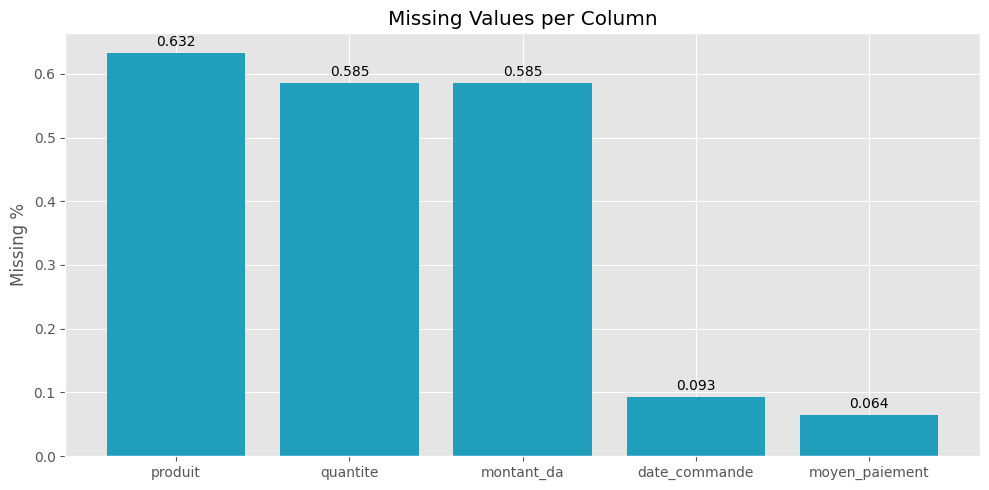

In [15]:
missing_data = round(((df.isna().sum()) / len(df) * 100), 3).sort_values(ascending=False).head()
x = missing_data.index
y = missing_data.values


fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(x, y, color='#219ebc')

ax.bar_label(bars, padding=3)

ax.set_ylabel('Missing %')
ax.set_title('Missing Values per Column')

plt.tight_layout()
plt.savefig('missing_values_plot.png')

On constate que le pourcentage des valeurs perdues de 'montant_da' est egale au pourcentage des valeurs perdues de 'quantite'.

### Other missing values 

#### nouveau_ou_fidele

In [16]:
df['nouveau_ou_fidele'].value_counts()

nouveau_ou_fidele
New          8749
Returning    8403
Unknown       101
Name: count, dtype: int64

The 'Unknown' represents a missing value.

#### categorie_produit 

In [17]:
df['categorie_produit'].value_counts()

categorie_produit
Électricité                       8272
Sanitaire                         6127
Pièces de rechange pour S.A.V.    1423
Non catégorisé                    1151
Menuiserie                         240
Électroménager                      36
Hydraulique                          4
Name: count, dtype: int64

The 'Non catégorisé' represents a missing value.

In [18]:
df['categorie_produit'] = df['categorie_produit'].replace({'Non catégorisé' : np.nan})

In [19]:
def inferer_categorie(nom):
    if pd.isna(nom):
        return 'Non catégorisé'
    
    # Normalize input
    nom = nom.lower()
    
    # Define mapping of categories and their associated keywords
    category_map = {
        'Sanitaire': [
            'chaudière', 'chauffe-eau', 'robinet', 'mitigeur', 'sanitaire', 'plomberie',
            'pressostat', 'vanne', 'tuyau', 'sèche-serviettes barres rondes 80 cm',
            'sl-dl32 boiler', 'multilayer faucet', 'gas block',
            'pressure switch', 'applique murale femelle 16x1/2"', 
            '160° burnt gas thermal switch', 'Kitchen faucet (G1 / 2)', 'B10-21mbar regulator',
            'Expansion vessel 8L', 'Bathtub BS65', '16x3 / 4 "male wall light',
            'Plate heat exchanger 12 L', 'Infrared sink', 'Exchanger 10L', '160° burnt gas thermal switch', 'boiler', 'bathtub',
            'Echangeur', 'Sèche-serviettes barres plates 80 cm - Blanc', 'Sèche-serviettes barres plates 80 cm - Gris',
            'Double Kitchen faucet (G1/2)', 'Gas gate', 'Expansion vessel 6L', 'Plate heat exchanger 16','Double Kitchen faucet (G1/2)',
            'Sèche-serviettes barres plates 80 cm - Noir', 'Sèche-serviettes barres plates 80 cm - Noir'
        ],
        'Électricité': [
            'disjoncteur', 'interrupteur', 'prise', 'câble', 'électrique', 'luminaire', 
            'ampoule', 'tableau', 'détecteur', 'doorbell', 'electric lock', 'voltage', 
            'adjustable voltage and current protector', 'socket without earth noor', 
            'satellite socket noor', 'dc 15v/1a adapter/transformer', 'adapter/ transformer dc', 
            'socket with earth +2 usb acrylic - black', 'adjustable voltage', 
            'triple ignition switch noor', 'noor telephone socket', 'moniteur', 'monitor', 
            'white monitor', '2-wire monitor with touch buttons', '7 inch white monitor', 
            'simple color videophone - black', 'remote switch', 'acrylic double ignition switch - black',
            'SINGLE-PHASE MARKER', 'Single switch', 'Temperature switch 95°C', 'Acrylic Single Ignition Switch - Golden',
            'rallonge', 'COMBINED INTERCOM', 'timer', 'Level relay', 'Phase relay with display', 
            'Protecteur de tension et courant réglable PTDR', 'Analog programmable clock', 'Digital programmable clock',
            '1 gang 2 way switch NOOR', 'NOOR', '63 A adjustable voltage protector', 'adjustable protective grip',
            'Simple color videophone - White', 'Acrylic Single Ignition Switch - Black', 'Schuko Socket NIR',
            'Acrylic Single Ignition Switch - Black', 'AUDIO INTERCOM PACK', 'Main heat exchanger - 24KW', '6L control block',
            'Diaphragm - Control block', 'Acrylic two-way switch - Golden', 'Double Acrylic Two-Way Switch - Black', 'Acrylic two-way switch - Black',
            'Double Single Acrylic Socket - Black', 'Double Acrylic Two-Way Switch - Black', 'Double Single Acrylic Socket - Black',
            'Acrylic Double Ignition Switch - Golden', 'Acrylic two-way switch - Black', 'Double Single Acrylic Socket - Golden',
            'Acrylic two-way switch - Black', 'Acrylic two-way switch - Black', 'Double Acrylic Two-Way Switch - Black',
            'Socket with Earth +2 USB Acrylic - Golden', 'Acrylic Double Ignition Switch - Drink', 'Socket with Earth +2 USB Acrylic - Golden',
            '1 gang 2 way switch NIR', 'LARP pilot'
            
            
        ],
        'Menuiserie': [
            'porte', 'fenêtre', 'menuiserie', 'aluminium', 'vitrage', 'serrure', 'poignée'
        ],
        'Pièces de rechange pour S.A.V.': [
            'capteur de débit', 'echangeur de chaleur principal', 
            'rallonge du conduit de fumée concentrique', 'vase d’expansion',
            '56W fan', 'Grundfos', 'Expansion vessel 10L', 'Multilayer male valve 16x1 / 2' , '45W fan', 'Expansion vessel 6L',
            'grundfos 76w pump', '5-way distributor', '4-way distributor', '10l control block', 'Double fitting valve (G1 / 2)' ,
            'Relief valve', '3-way valve motor','Double connection valve (G3 / 4)','3-way valve motor','Double connection valve (G3 / 4)',
            '35W fan', 'Relief valve'
        ],
        'Électroménager': [],
        'Hydraulique': [],
    }
    
    # Check if any keyword matches
    for category, keywords in category_map.items():
        if any(keyword.lower() in nom for keyword in keywords):
            return category
            
    return 'Non catégorisé'

# Apply the function
df['categorie_produit'] = df['categorie_produit'].fillna(df['produit'].apply(inferer_categorie))

In [20]:
df['categorie_produit'].value_counts()

categorie_produit
Électricité                       8813
Sanitaire                         6375
Pièces de rechange pour S.A.V.    1676
Menuiserie                         240
Non catégorisé                     109
Électroménager                      36
Hydraulique                          4
Name: count, dtype: int64

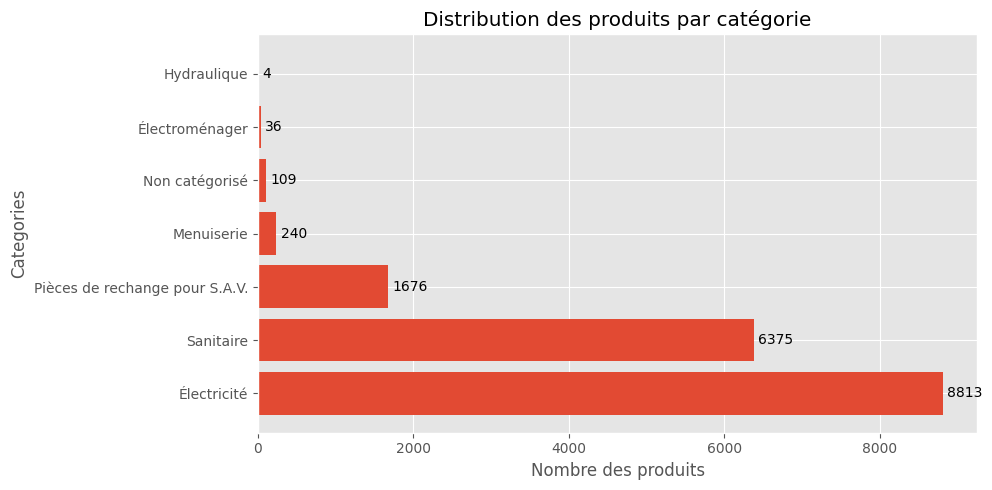

In [21]:
counts = df['categorie_produit'].value_counts()
x = counts.index
y = counts.values

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(x, y)
ax.bar_label(bars, padding=3)


plt.xlabel('Nombre des produits')
plt.ylabel('Categories')
plt.title('Distribution des produits par catégorie') 

plt.tight_layout()
plt.savefig('categorie_produits.png')

1. Concentration massive:
    On observe une concentration très forte sur deux catégories principales : « Électricité » (8 813 produits) et « Sanitaire » (6 375          produits).

     À elles seules, ces deux catégories représentent la grande majorité de catalogue. En terme de gestion des stocks, ce sont probablement      les catégories prioritaires en termes de gestion logistique et de rotation.

3. Déséquilibre important du catalogue
    Il existe un écart colossal entre le haut et le bas du classement :

    La catégorie « Électricité » est plus de 2 000 fois plus importante que la catégorie « Hydraulique » (4 produits).

    Cela suggère que votre entreprise est spécialisée dans les domaines électrique et sanitaire, tandis que les autres catégories semblent      être soit secondaires, soit en phase de test/abandon, soit très spécialisées.

3. La catégorie "Non catégorisé"
    Vous avez 109 produits classés dans « Non catégorisé ».

**Insight** : C'est une dette de données. Ces 109 produits manquent de visibilité pour vos clients ou vos rapports. Il serait judicieux de les réaffecter dans les catégories existantes ou de créer une catégorie plus pertinente pour eux.

4. La longue traîne (Long Tail)
    Les catégories situées en bas du graphique (« Menuiserie », « Électroménager », « Hydraulique ») forment ce qu'on appelle la "longue        traîne".

**Action suggérée** : Vous devez vous demander si ces petites catégories sont rentables. Si elles coûtent cher à maintenir (stockage, référencement, gestion des fournisseurs) pour un volume de vente très faible, il pourrait être stratégique de réduire ces références pour vous concentrer sur vos "top performers".

In [29]:
valeurs_a_remplacer = ['non categorisee', 'unknown', 'None', '']
df.replace(valeurs_a_remplacer, np.nan, inplace=True)

df_subset = df.drop(columns=['moyen_paiement', 'id_commande_anon', 'id_client', 'type_client', 'wilaya', 'statut_commande'])

cols_a_analyser = df_subset.columns.tolist()

df_missing = df.groupby('moyen_paiement')[cols_a_analyser].apply(lambda x: x.isnull().sum())

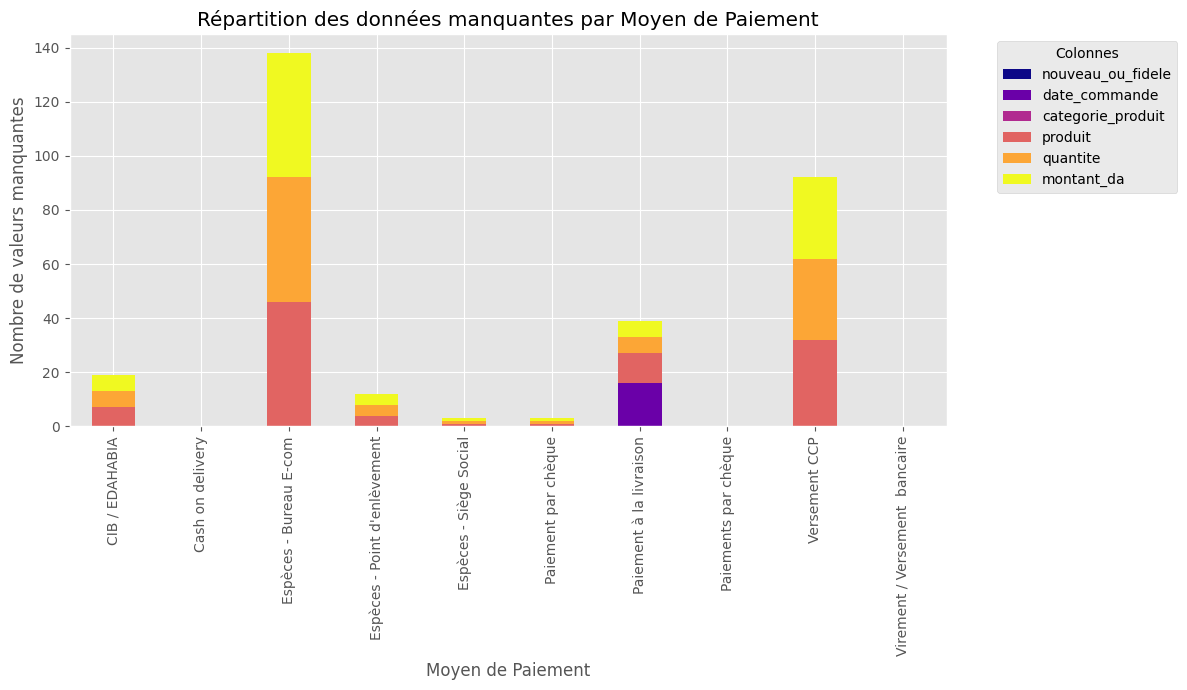

In [30]:
ax = df_missing.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='plasma')

plt.title('Répartition des données manquantes par Moyen de Paiement')
plt.ylabel('Nombre de valeurs manquantes')
plt.xlabel('Moyen de Paiement')
plt.legend(title='Colonnes', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('mv_moyen_paiement.png')

#### Insights:
Ce graphique montre combien de valeurs manquantes existent dans chaque colonne, ventilées par moyen de paiement. Chaque barre empilée représente un moyen de paiement, et les couleurs indiquent quelle(s) colonne(s) ont des NaN dans ces transactions.
Ce qu'on observe :
* **Espèces - Bureau E-com** est de loin le plus problématique (~140 valeurs manquantes), dominé par montant_da (jaune) et produit (rose/rouge). C'est anormal — des transactions en espèces devraient avoir un montant et un produit.
* **Versement CCP** est le deuxième (~92 valeurs manquantes), même pattern : montant_da + produit manquants.
* **Paiement à la livraison** (~40 valeurs) a en plus une grosse portion date_commande (violet) et nouveau_ou_fidele (bleu foncé) — ce qui est unique à ce mode de paiement.
* **CIB / EDAHABIA** (~20 valeurs), Espèces - Point d'enlèvement (~12) et Paiement par chèque (~3) ont des niveaux modérés.
* **Cash on delivery, Paiements par chèque, Virement / Versement bancaire** : quasiment aucune valeur manquante qui signifie données bien renseignées.



#### Problemes:
* **Problème 1** — montant_da et quantite absents ensemble
leurs pourcentages de NaN sont égaux. Le groupby confirme que leurs NaN apparaissent dans les mêmes modes de paiement (Espèces Bureau, CCP). Ce sont probablement les mêmes lignes avec montant_da ET quantite nuls simultanément — probablement des commandes annulées ou non finalisées.
* **Problème 2** — produit manquant dans les paiements en espèces et CCP
Une transaction en espèces sans produit identifié = soit une erreur de saisie, soit une catégorie "divers" non enregistrée. Ça impacte directement le RFM et le churn.
* **Problème 3** — date_commande et nouveau_ou_fidele manquants surtout en "Paiement à la livraison"

### dealing with missing values

* supprimer les lignes qui contiennet ce triplet 'produit','quantite', 'montant_da' vide.
* On utilise les flags (0/1) qui demontre l'abscence des valeurs sans les supprimer car cette meme abscence peut avoir des indications qui nous aide aux analyses. 
* les dates sont en ordre donc on peut les estimer

In [36]:
# supprimer le triplet vide
df.dropna(subset=['montant_da', 'produit', 'quantite'], inplace=True)

,id_commande_anon,id_client,type_client,nouveau_ou_fidele,date_commande,wilaya,categorie_produit,produit,quantite,montant_da,moyen_paiement,statut_commande,mois,annee,trimestre,jour_semaine,est_hiver,est_ete
id_transaction,,,,,,,,,,,,,,,,,,
153,13632,CLT_00056,B2C,Returning,2023-03-17,Batna,Électricité,Pack ruban LED 1 ligne 9W lumière blanche avec...,10.0,-182.35,Paiement à la livraison,Terminée,3.0,2023.0,1.0,4.0,0,0
197,11102,CLT_01121,B2C,New,2022-02-18,Béjaïa,Électricité,Pack Visiophone Complet 472-C,1.0,-4244.23,Paiement à la livraison,Terminée,2.0,2022.0,1.0,4.0,1,0
402,15869,CLT_03795,B2C,New,2023-12-09,Alger,Électricité,Pack ruban LED 1 ligne 9W lumière jaune avec t...,1.0,-18.24,Paiement à la livraison,Terminée,12.0,2023.0,4.0,5.0,1,0
677,11577,CLT_00254,B2C,New,2022-05-30,Ghardaïa,Électricité,Pack Visiophone Complet 472-C,1.0,-4244.23,Paiement à la livraison,Terminée,5.0,2022.0,2.0,0.0,0,0
775,14668,CLT_00700,B2C,New,2023-08-04,Bordj Bou Arreridj,Électricité,Pack Visiophone Complet 472-C,1.0,-4308.06,Paiement à la livraison,Terminée,8.0,2023.0,3.0,4.0,0,1
920,15215,CLT_03716,B2C,New,2023-10-09,Alger,Électricité,Pack Ruban LED 2 lignes 14W (lumière jaune) av...,1.0,-18.24,Paiement à la livraison,Terminée,10.0,2023.0,4.0,0.0,0,0
1196,14054,CLT_03080,B2C,Returning,2023-05-14,Tlemcen,Électricité,Pack ruban LED 1 ligne 9W lumière jaune avec t...,1.0,-18.24,Paiement à la livraison,Terminée,5.0,2023.0,2.0,6.0,0,0
1409,16296,CLT_02820,B2C,New,2024-01-15,Tipaza,Électricité,Pack Visiophone Complet 472-C,1.0,-4308.06,Paiement à la livraison,Terminée,1.0,2024.0,1.0,0.0,1,0
1762,11115,CLT_03080,B2C,Returning,2022-02-20,Adrar,Électricité,Pack Visiophone Complet 472-C,1.0,-4244.23,Paiement à la livraison,Terminée,2.0,2022.0,1.0,6.0,1,0


In [ ]:
# flags
df['flag_produit_manquant'] = df['produit'].isna()
df['produit'] = df['produit'].fillna('Inconnu')
df['flag_date_imputee'] = df['date_commande'].isna()

In [ ]:
# estimer date
df = df.sort_values('id_commande_anon')
df['date_commande'] = df['date_commande'].ffill().bfill()   
df = df.sort_index()

### Client analysis

In [50]:
PALETTE = {
    'blue':   '#2a78d6',
    'teal':   '#1baf7a',
    'amber':  '#eda100',
    'red':    '#e34948',
    'violet': '#4a3aa7',
    'gray':   '#888780',
    'pink':   '#e87ba4',
}


In [48]:
df['type_client'].value_counts()

type_client
B2C    17149
B2B      114
Name: count, dtype: int64

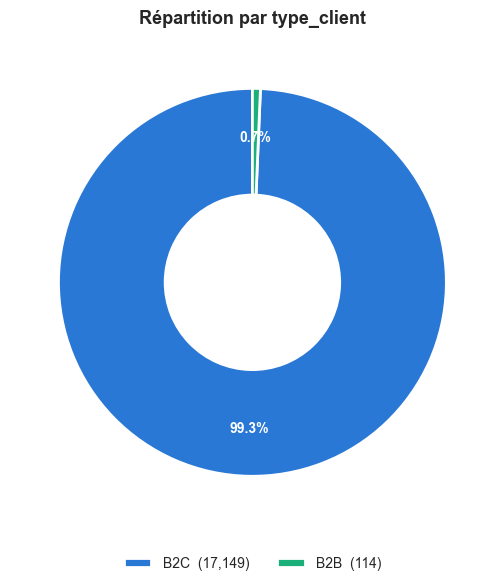

In [57]:
tc_counts = df['type_client'].value_counts(dropna=False).fillna(0)
tc_counts.index = tc_counts.index.fillna('Inconnu')
colors_tc = [PALETTE['blue'], PALETTE['teal'], PALETTE['amber'],
             PALETTE['violet'], PALETTE['gray']][:len(tc_counts)]

fig, ax = plt.subplots(figsize=(7, 6))

wedges, texts, autotexts = ax.pie(
    tc_counts,
    labels=None,
    autopct='%1.1f%%',
    colors=colors_tc,
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2)
)
for t in autotexts:
    t.set_fontsize(10)
    t.set_color('white')
    t.set_fontweight('bold')

ax.legend(
    wedges, [f"{k}  ({v:,})" for k, v in tc_counts.items()],
    loc='lower center', bbox_to_anchor=(0.5, -0.12),
    fontsize=10, ncol=2, frameon=False
)
ax.set_title('Répartition par type_client', fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('fig1_type_client_donut.png', dpi=150, bbox_inches='tight')
plt.show()

B2C = 99.3% (17 149 tx), B2B = 0.7% (114 tx). Le dataset est quasi-exclusivement B2C. Le B2B est trop petit pour des analyses statistiques robustes seul — à noter pour le jury : les modèles RFM et churn seront entraînés sur B2C, avec peut-être une analyse B2B séparée et descriptive uniquement.

In [49]:
df['nouveau_ou_fidele'].value_counts()

nouveau_ou_fidele
New          8755
Returning    8407
Name: count, dtype: int64

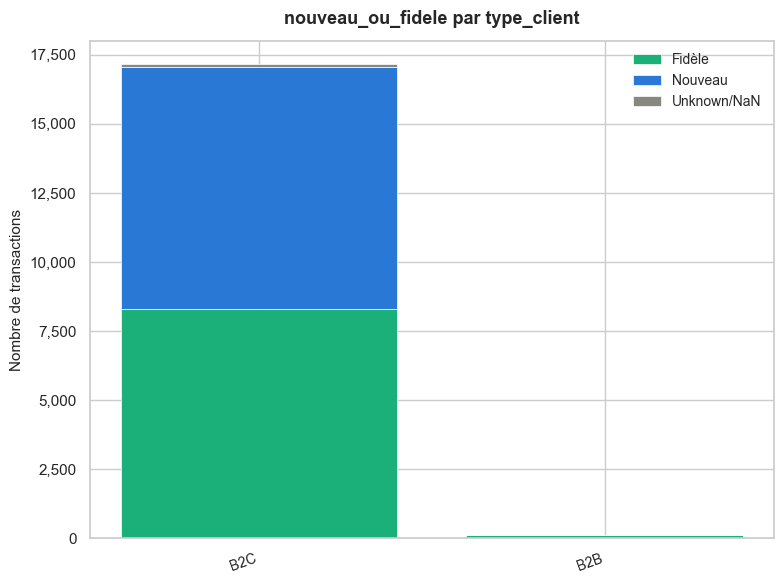

In [58]:
order_tc    = df['type_client'].value_counts().index.tolist()
tc_counts   = df['type_client'].value_counts(dropna=False).fillna(0)
tc_counts.index = tc_counts.index.fillna('Inconnu')

def get_nf_counts(tc_val):
    sub = df[df['type_client'] == tc_val]['nouveau_ou_fidele']
    fidele  = (sub == 'Fidele').sum() + (sub == 'Returning').sum()
    nouveau = (sub == 'Nouveau').sum() + (sub == 'New').sum()
    unknown = sub.isna().sum()
    return fidele, nouveau, unknown

fidele_vals, nouveau_vals, unknown_vals = [], [], []
for tc in order_tc:
    f, n, u = get_nf_counts(tc)
    fidele_vals.append(f)
    nouveau_vals.append(n)
    unknown_vals.append(u)

x = __import__('numpy').arange(len(order_tc))

fig, ax = plt.subplots(figsize=(8, 6))
bars_f = ax.bar(x, fidele_vals,  label='Fidèle',      color=PALETTE['teal'], edgecolor='white', linewidth=0.5)
bars_n = ax.bar(x, nouveau_vals, label='Nouveau',     color=PALETTE['blue'], edgecolor='white', linewidth=0.5,
                bottom=fidele_vals)
bars_u = ax.bar(x, unknown_vals, label='Unknown/NaN', color=PALETTE['gray'], edgecolor='white', linewidth=0.5,
                bottom=[f + n for f, n in zip(fidele_vals, nouveau_vals)])

ax.set_xticks(x)
ax.set_xticklabels(order_tc, rotation=20, ha='right', fontsize=10)
ax.set_ylabel('Nombre de transactions', fontsize=11)
ax.set_title('nouveau_ou_fidele par type_client', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=10, frameon=False)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v):,}'))

plt.tight_layout()
plt.savefig('fig2_nof_par_type_client.png', dpi=150, bbox_inches='tight')
plt.show()

Chez B2C : New ≈ 8 755, Returning ≈ 8 407 — quasi équilibre, ce qui est bon signe pour un modèle de churn. Chez B2B les volumes sont trop faibles pour conclure.

### Flags, IQR & Calcul des seuils

In [55]:
valid = df[df['is_valid_monetary']].copy()

In [71]:
def iqr_bounds(series, factor=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return q1, q3, q1 - factor * iqr, q3 + factor * iqr

q1_m, q3_m, low_m, high_m = iqr_bounds(valid['montant_da'])
q1_q, q3_q, low_q, high_q = iqr_bounds(valid['quantite'].dropna())

# Flags outliers
df['flag_outlier_montant_haut'] = (df['montant_da'] > high_m) & df['is_valid_monetary']
df['flag_outlier_montant_bas']  = (df['montant_da'] < low_m)  & df['is_valid_monetary']
df['flag_outlier_quantite']     = df['quantite'] > high_q

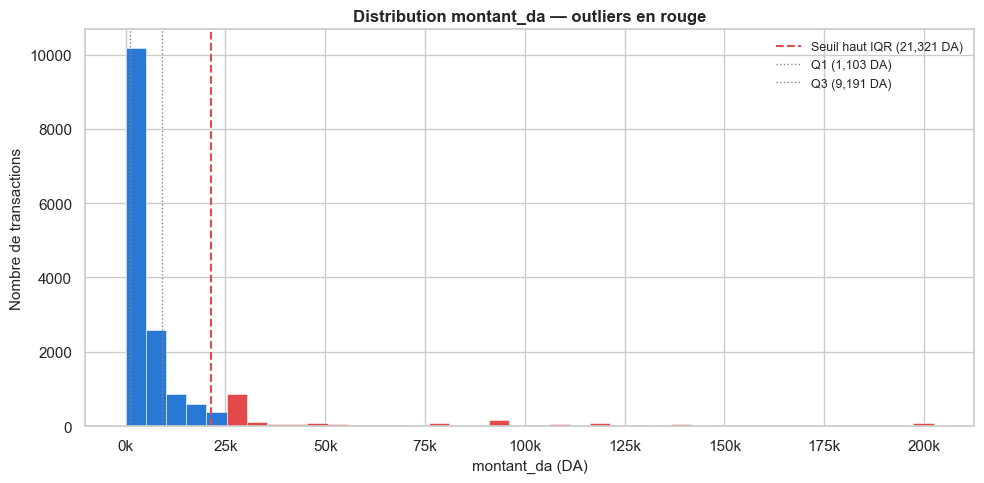

In [59]:
montant_plot = valid['montant_da'].clip(upper=valid['montant_da'].quantile(0.995))

fig, ax = plt.subplots(figsize=(10, 5))
counts, bin_edges, patches = ax.hist(montant_plot, bins=40,
                                     color=PALETTE['blue'], edgecolor='white', linewidth=0.4)
for patch, left in zip(patches, bin_edges[:-1]):
    if left > high_m:
        patch.set_facecolor(PALETTE['red'])
    elif left < max(low_m, 0):
        patch.set_facecolor(PALETTE['amber'])

ax.axvline(high_m, color=PALETTE['red'],  linestyle='--', linewidth=1.5,
           label=f'Seuil haut IQR ({high_m:,.0f} DA)')
ax.axvline(q1_m,   color=PALETTE['gray'], linestyle=':',  linewidth=1,
           label=f'Q1 ({q1_m:,.0f} DA)')
ax.axvline(q3_m,   color=PALETTE['gray'], linestyle=':',  linewidth=1,
           label=f'Q3 ({q3_m:,.0f} DA)')

ax.set_xlabel('montant_da (DA)', fontsize=11)
ax.set_ylabel('Nombre de transactions', fontsize=11)
ax.set_title('Distribution montant_da — outliers en rouge', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, frameon=False)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1000:.0f}k'))

plt.tight_layout()
plt.savefig('fig3_distribution_montant.png', dpi=150, bbox_inches='tight')
plt.show()

Distribution très asymétrique à droite (right-skewed) : la grande majorité des transactions sont sous 25k DA, avec une longue queue jusqu'à ~200k+ DA. Le seuil IQR (≈21 321 DA) capture bien la zone normale — les barres rouges après le seuil sont les outliers. Implication pour le modèle : log-transformer montant_da avant tout algorithme sensible à l'échelle (régression, clustering).

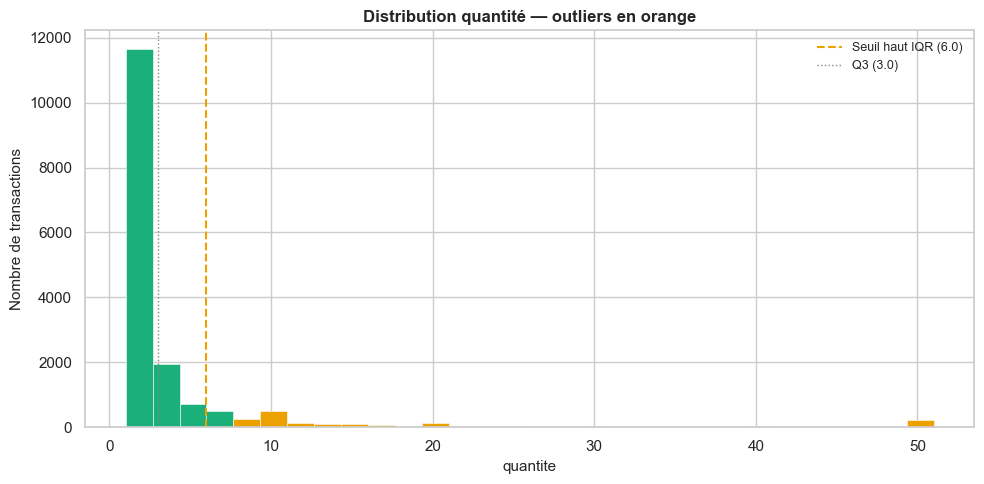

In [61]:
qte_plot = valid['quantite'].dropna().clip(upper=valid['quantite'].quantile(0.99))

fig, ax = plt.subplots(figsize=(10, 5))
counts_q, bin_edges_q, patches_q = ax.hist(qte_plot, bins=30,
                                            color=PALETTE['teal'], edgecolor='white', linewidth=0.4)
for patch, left in zip(patches_q, bin_edges_q[:-1]):
    if left > high_q:
        patch.set_facecolor(PALETTE['amber'])

ax.axvline(high_q, color=PALETTE['amber'], linestyle='--', linewidth=1.5,
           label=f'Seuil haut IQR ({high_q:.1f})')
ax.axvline(q3_q,   color=PALETTE['gray'],  linestyle=':',  linewidth=1,
           label=f'Q3 ({q3_q:.1f})')

ax.set_xlabel('quantite', fontsize=11)
ax.set_ylabel('Nombre de transactions', fontsize=11)
ax.set_title('Distribution quantité — outliers en orange', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig('fig4_distribution_quantite.png', dpi=150, bbox_inches='tight')
plt.show()

Encore plus extrême : la quasi-totalité des commandes ont quantité 1-3. Le seuil IQR est à 6 unités seulement — tout ce qui dépasse est statistiquement anormal. La barre à ~50 visible sur le graphe représente probablement quelques commandes B2B ou grossistes. La transaction à 1 920 unités est un outlier isolé à investiguer manuellement.

C:\Users\TRANSHOST\AppData\Local\Temp\ipykernel_12804\1166921299.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


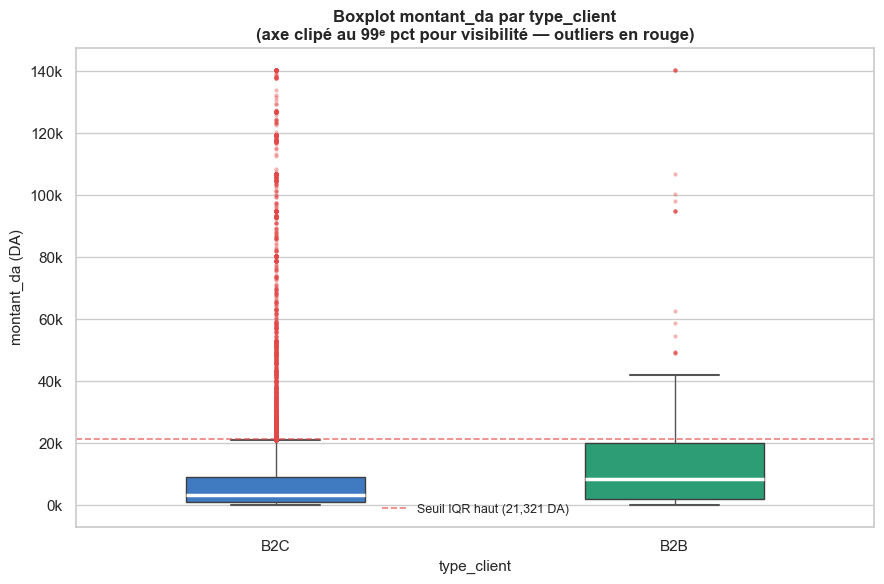

In [67]:
CAP_M = valid['montant_da'].quantile(0.99)

plot_df = valid[['type_client', 'montant_da']].copy()
plot_df['montant_clip'] = plot_df['montant_da'].clip(upper=CAP_M)

order_tc = df['type_client'].value_counts().index.tolist()
palette_tc = {tc: c for tc, c in zip(order_tc,
              [PALETTE['blue'], PALETTE['teal'], PALETTE['amber'],
               PALETTE['violet'], PALETTE['gray']])}

fig, ax = plt.subplots(figsize=(9, 6))

sns.boxplot(
    data=plot_df, x='type_client', y='montant_clip',
    order=order_tc, palette=palette_tc,
    width=0.45, linewidth=1.2,
    flierprops=dict(marker='o', markerfacecolor=PALETTE['red'],
                    markeredgecolor='none', markersize=3, alpha=0.4),
    medianprops=dict(color='white', linewidth=2.5),
    whiskerprops=dict(color='#555', linewidth=1),
    capprops=dict(color='#555', linewidth=1.5),
    boxprops=dict(linewidth=1),
    ax=ax
)

# Ligne de référence : seuil IQR haut
ax.axhline(high_m, color=PALETTE['red'], linestyle='--', linewidth=1.2, alpha=0.7,
           label=f'Seuil IQR haut ({high_m:,.0f} DA)')

# Annotation du clip
# ax.text(0.99, 0.97, f'Axe clipé au 99e pct ({CAP_M/1000:.0f}k DA)
# '
#         f'Max réel ≈ {valid["montant_da"].max()/1_000_000:.2f}M DA',
#         transform=ax.transAxes, ha='right', va='top',
#         fontsize=8.5, color=PALETTE['gray'],
#         bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

ax.set_xlabel('type_client', fontsize=11)
ax.set_ylabel('montant_da (DA)', fontsize=11)
ax.set_title('Boxplot montant_da par type_client\n'
             '(axe clipé au 99ᵉ pct pour visibilité — outliers en rouge)',
             fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1000:.0f}k'))
ax.legend(fontsize=9, frameon=False)
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('fig5_boxplot_type_client.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\TRANSHOST\AppData\Local\Temp\ipykernel_12804\2926979177.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


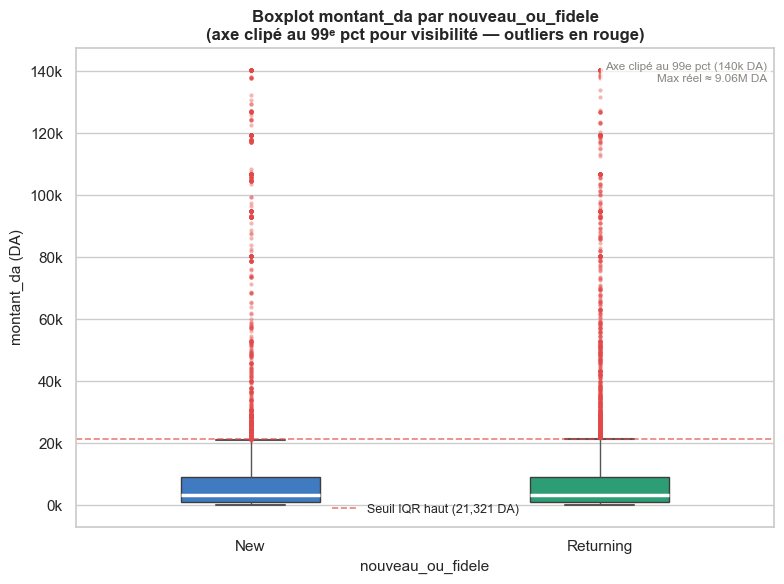

In [69]:
CAP_M = valid['montant_da'].quantile(0.99)

nof_order   = ['New', 'Returning']
palette_nof = {'New': PALETTE['blue'], 'Returning': PALETTE['teal']}

plot_nof = valid[valid['nouveau_ou_fidele'].isin(nof_order)].copy()
plot_nof['montant_clip'] = plot_nof['montant_da'].clip(upper=CAP_M)

fig, ax = plt.subplots(figsize=(8, 6))

sns.boxplot(
    data=plot_nof, x='nouveau_ou_fidele', y='montant_clip',
    order=nof_order, palette=palette_nof,
    width=0.4, linewidth=1.2,
    flierprops=dict(marker='o', markerfacecolor=PALETTE['red'],
                    markeredgecolor='none', markersize=3, alpha=0.4),
    medianprops=dict(color='white', linewidth=2.5),
    whiskerprops=dict(color='#555', linewidth=1),
    capprops=dict(color='#555', linewidth=1.5),
    boxprops=dict(linewidth=1),
    ax=ax
)

ax.axhline(high_m, color=PALETTE['red'], linestyle='--', linewidth=1.2, alpha=0.7,
           label=f'Seuil IQR haut ({high_m:,.0f} DA)')

ax.text(0.99, 0.97, f'Axe clipé au 99e pct ({CAP_M/1000:.0f}k DA)\n'
        f'Max réel ≈ {valid["montant_da"].max()/1_000_000:.2f}M DA',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=8.5, color=PALETTE['gray'],
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

ax.set_xlabel('nouveau_ou_fidele', fontsize=11)
ax.set_ylabel('montant_da (DA)', fontsize=11)
ax.set_title('Boxplot montant_da par nouveau_ou_fidele\n'
             '(axe clipé au 99ᵉ pct pour visibilité — outliers en rouge)',
             fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1000:.0f}k'))
ax.legend(fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig('fig6_boxplot_fidelite.png', dpi=150, bbox_inches='tight')
plt.show()

Pourquoi les anciens boxplots étaient illisibles : un outlier à 9M DA étire l'axe Y sur 9 000k — la boîte (Q1=1k DA à Q3=9k DA) occupait littéralement 0.1% de la hauteur du graphe.
Avec le clip au 99e percentile :

Fig 5 (par type_client) : B2C et B2B ont des médianes proches (~3k DA), mais B2B a une variance plus large — cohérent avec des achats professionnels moins standardisés.
Fig 6 (par fidélité) : Returning a une médiane légèrement supérieure à New — les clients fidèles ont tendance à commander des montants plus élevés, ce qui soutient l'hypothèse que la rétention a de la valeur business.

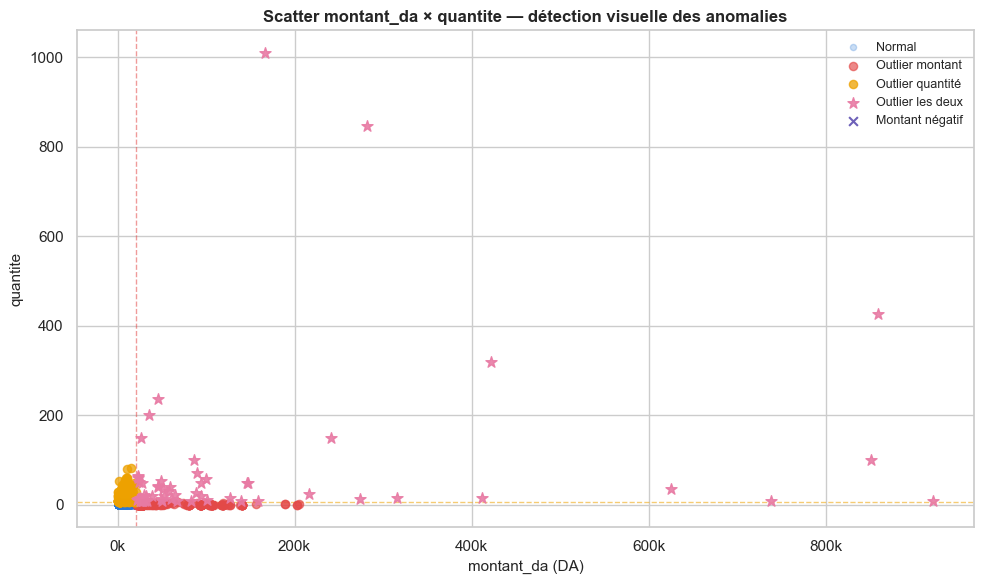

In [74]:
sample = valid.dropna(subset=['montant_da', 'quantite']).sample(
    min(3000, len(valid)), random_state=42).copy()

# Recalcul des flags directement sur sample (à partir des seuils déjà connus)
sample['flag_outlier_montant_haut'] = sample['montant_da'] > high_m
sample['flag_outlier_quantite']     = sample['quantite']   > high_q
sample['flag_montant_negatif']      = sample['montant_da'] < 0

is_out_m  = sample['flag_outlier_montant_haut']
is_out_q  = sample['flag_outlier_quantite']
is_neg    = sample['flag_montant_negatif']
is_both   = is_out_m & is_out_q
is_normal = ~is_out_m & ~is_out_q & ~is_neg

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(sample.loc[is_normal,           'montant_da'], sample.loc[is_normal,           'quantite'],
           color=PALETTE['blue'],   alpha=0.25, s=20, label='Normal',            zorder=2)
ax.scatter(sample.loc[is_out_m & ~is_both, 'montant_da'], sample.loc[is_out_m & ~is_both, 'quantite'],
           color=PALETTE['red'],    alpha=0.65, s=35, label='Outlier montant',   zorder=3)
ax.scatter(sample.loc[is_out_q & ~is_both, 'montant_da'], sample.loc[is_out_q & ~is_both, 'quantite'],
           color=PALETTE['amber'],  alpha=0.75, s=35, label='Outlier quantité',  zorder=3)
ax.scatter(sample.loc[is_both,             'montant_da'], sample.loc[is_both,             'quantite'],
           color=PALETTE['pink'],   alpha=0.9,  s=70, marker='*',
           label='Outlier les deux', zorder=4)
ax.scatter(sample.loc[is_neg,              'montant_da'], sample.loc[is_neg,              'quantite'],
           color=PALETTE['violet'], alpha=0.8,  s=40, marker='x',
           label='Montant négatif',  zorder=4)

ax.axvline(high_m, color=PALETTE['red'],   linestyle='--', linewidth=1, alpha=0.55)
ax.axhline(high_q, color=PALETTE['amber'], linestyle='--', linewidth=1, alpha=0.55)

ax.set_xlabel('montant_da (DA)', fontsize=11)
ax.set_ylabel('quantite', fontsize=11)
ax.set_title('Scatter montant_da × quantite — détection visuelle des anomalies',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, frameon=False)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1000:.0f}k'))

plt.tight_layout()
plt.savefig('fig7_scatter_anomalies.png', dpi=150, bbox_inches='tight')
plt.show()